In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [14]:
from itertools import combinations
from collections import Counter
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer, categorize_files
from DNAnet.data.parsing.file_parsing import find_files_by_suffix

import matplotlib.pyplot as plt
import numpy as np


In [5]:
def extract_all_pairs(files):
    pairs = []
    for f in files:
        ids = ProvedItFileCategorizer.extract_contributor_ids(f.name)
        # Only consider files with at least 2 contributors
        if len(ids) >= 2:
            # Get all unique pairs (order doesn't matter)
            pairs.extend(combinations(sorted(ids), 2))
    return pairs

In [6]:

hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"

hid_files = find_files_by_suffix(hid_files_path, ".hid")


In [9]:
categorized_files = categorize_files(hid_files, ProvedItFileCategorizer())
mixture_samples = categorized_files["sample"]

In [10]:
len(mixture_samples)

176

In [17]:
pairs = extract_all_pairs(hid_files)
pairs_count = Counter(pairs)

In [18]:
pairs_count

Counter({(33, 34): 122,
         (36, 37): 107,
         (29, 50): 100,
         (44, 45): 99,
         (31, 32): 98,
         (37, 38): 97,
         (29, 49): 84,
         (49, 50): 84,
         (30, 31): 83,
         (46, 47): 83,
         (48, 49): 82,
         (36, 38): 82,
         (37, 39): 81,
         (38, 39): 81,
         (42, 43): 80,
         (35, 36): 75,
         (33, 35): 73,
         (34, 35): 73,
         (30, 32): 67,
         (32, 33): 66,
         (32, 34): 66,
         (36, 39): 66,
         (44, 46): 66,
         (45, 46): 66,
         (40, 41): 64,
         (35, 37): 59,
         (31, 33): 50,
         (31, 34): 50,
         (44, 47): 50,
         (45, 47): 50,
         (29, 48): 50,
         (48, 50): 50,
         (47, 48): 49,
         (41, 42): 47,
         (41, 43): 47,
         (39, 40): 46,
         (33, 36): 41,
         (34, 36): 41,
         (30, 33): 34,
         (30, 34): 34,
         (35, 38): 34,
         (35, 39): 34,
         (46, 48): 33,
        

In [19]:
def plot_arc_diagram(pairs, num_ids=50):
    plt.figure(figsize=(16, 4))
    y = np.zeros(num_ids)
    x = np.arange(1, num_ids + 1)
    plt.scatter(x, y, s=50, color='black')

    for a, b in pairs:
        # Draw an arc between a and b
        mid = (a + b) / 2
        radius = abs(b - a) / 2
        theta = np.linspace(0, np.pi, 100)
        arc_x = mid + radius * np.cos(theta)
        arc_y = radius * np.sin(theta)
        plt.plot(arc_x, arc_y, color='blue', alpha=0.3)

    plt.yticks([])
    plt.xlabel("Contributor ID")
    plt.title("Contributor Co-occurrence Arc Diagram")
    plt.show()

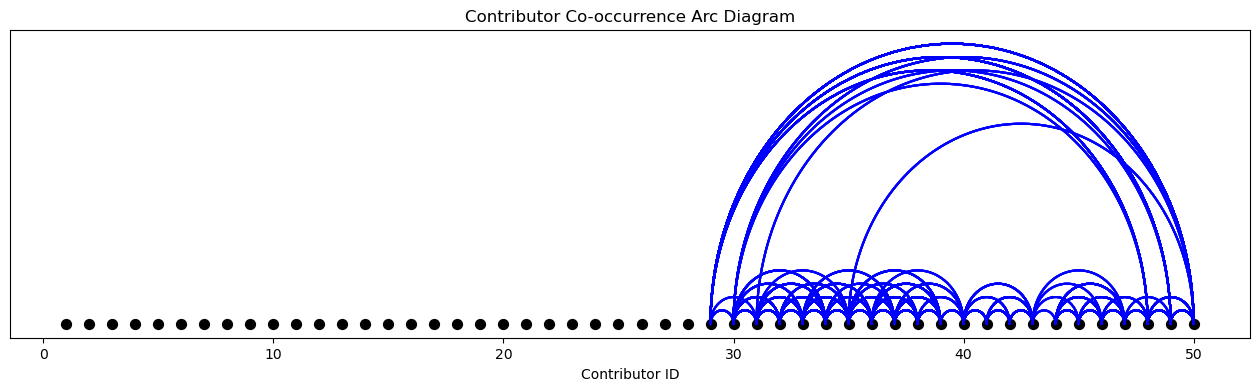

In [20]:
plot_arc_diagram(pairs)